# ZOD LiDAR Exploration (for pedestrian detection)

This notebook provides a complete walkthrough of:

1. What files exist per keyframe (camera, annotation, lidar).
2. Why there are many `.npy` LiDAR files in one keyframe directory.
3. What each LiDAR `.npy` contains and how to visualize it.
4. How pedestrian annotations are represented (2D + 3D fields).
5. How camera and LiDAR relate through calibration, with a projection sanity check.
6. How this maps to BEVFusion-style feature-space construction.

In [28]:
# Core imports for data loading + plotting.
from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Consistent plotting defaults make visual comparisons easier across cells.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"

# Dataset root for original ZOD single-frame data.
ORIGINAL_ZOD_ROOT = Path("/home/edgelab/zod_dino_data/train2017")

# Frame selection is discovered dynamically from available data.
print(f"ORIGINAL_ZOD_ROOT exists: {ORIGINAL_ZOD_ROOT.exists()}")
print(f"ORIGINAL_ZOD_ROOT: {ORIGINAL_ZOD_ROOT}")

ORIGINAL_ZOD_ROOT exists: True
ORIGINAL_ZOD_ROOT: /home/edgelab/zod_dino_data/train2017


## 1) Locate keyframes that actually have LiDAR sweeps

Some frame folders only have metadata/annotations, while others also include `lidar_velodyne/`.
The first step is to scan the dataset and pick a frame that definitely has:

- `lidar_velodyne/*.npy`
- `annotations/object_detection.json`
- camera metadata in `info.json`

### Note from ZOD docs

ZOD says annotations are for the camera-LiDAR keyframe pair, not all surrounding sweeps.

That already hints at why multiple LiDAR `.npy` files exist per keyframe folder:
- one camera keyframe timestamp
- several LiDAR sweeps around that time
- labels aligned to keyframe context

In [29]:
def _read_json(path: Path):
    # Tiny helper so I don't repeat try/except in every cell.
    try:
        return json.loads(path.read_text())
    except Exception as e:
        print(f"Could not read JSON: {path}\n{e}")
        return None


def _iso_to_dt(s: str) -> datetime:
    # Z-suffixed timestamp helper.
    return datetime.fromisoformat(s.replace("Z", "+00:00"))


def _list_npy_files(lidar_dir: Path) -> list[Path]:
    # Sort by filename so timestamps appear in order.
    return sorted([p for p in lidar_dir.glob("*.npy")])


def _frame_has_lidar_and_od(frame_dir: Path) -> bool:
    lidar_dir = frame_dir / "lidar_velodyne"
    od_json = frame_dir / "annotations" / "object_detection.json"
    if not lidar_dir.exists() or not od_json.exists():
        return False
    return len(_list_npy_files(lidar_dir)) > 0

In [30]:
# Top-level frame directories (single frame ids).
frame_dirs = sorted([p for p in ORIGINAL_ZOD_ROOT.iterdir() if p.is_dir()])
print(f"Total frame directories found: {len(frame_dirs):,}")

candidates: list[Path] = []
for fd in frame_dirs:
    if _frame_has_lidar_and_od(fd):
        candidates.append(fd)
    if len(candidates) >= 5:
        # A small subset is enough for this exploration.
        break

print(f"Candidate frames with LiDAR + object_detection: {len(candidates)}")
for c in candidates:
    lidar_count = len(_list_npy_files(c / 'lidar_velodyne'))
    print(f"- {c.name}: {lidar_count} npy files")

Total frame directories found: 100,000
Candidate frames with LiDAR + object_detection: 5
- 000000: 11 npy files
- 000001: 12 npy files
- 000002: 12 npy files
- 000003: 12 npy files
- 000004: 12 npy files


In [31]:
# First valid candidate for reproducible exploration.
FRAME_DIR = candidates[0]
print(f"Using FRAME_DIR: {FRAME_DIR}")

INFO_PATH = FRAME_DIR / "info.json"
META_PATH = FRAME_DIR / "metadata.json"
CALIB_PATH = FRAME_DIR / "calibration.json"
EGO_PATH = FRAME_DIR / "ego_motion.json"
OD_PATH = FRAME_DIR / "annotations" / "object_detection.json"
LIDAR_DIR = FRAME_DIR / "lidar_velodyne"

info = _read_json(INFO_PATH)
meta = _read_json(META_PATH)
calib = _read_json(CALIB_PATH)
ego_motion = _read_json(EGO_PATH)
od = _read_json(OD_PATH)

print("Loaded JSON assets:")
for p in [INFO_PATH, META_PATH, CALIB_PATH, EGO_PATH, OD_PATH]:
    print(f"- {p.name}: {'OK' if p.exists() else 'MISSING'}")

print(f"\nNum object annotations: {len(od) if isinstance(od, list) else 'N/A'}")
print(f"Frame metadata says num_pedestrians: {meta.get('num_pedestrians') if isinstance(meta, dict) else 'N/A'}")

Using FRAME_DIR: /home/edgelab/zod_dino_data/train2017/000000
Loaded JSON assets:
- info.json: OK
- metadata.json: OK
- calibration.json: OK
- ego_motion.json: OK
- object_detection.json: OK

Num object annotations: 281
Frame metadata says num_pedestrians: 40


## 2) Why are there many LiDAR `.npy` files per keyframe?

Short answer: ZOD stores a temporal window around the keyframe.

- `info.json` has `start_time`, `keyframe_time`, `end_time`.
- It also lists many `lidar_frames.velodyne` timestamps within that interval.
- A single camera keyframe gets paired with multiple surrounding LiDAR sweeps.

These `.npy` files are not duplicates. They are sequential sweeps across a short time window.

In [32]:
# Compare what info.json expects vs what is physically present in this local copy.
lidar_manifest = info.get("lidar_frames", {}).get("velodyne", []) if isinstance(info, dict) else []
expected_paths = [Path(x["filepath"]).name for x in lidar_manifest]
present_paths = [p.name for p in _list_npy_files(LIDAR_DIR)]

expected_set = set(expected_paths)
present_set = set(present_paths)

missing_local = sorted(expected_set - present_set)
extra_local = sorted(present_set - expected_set)

print(f"Expected sweeps from info.json: {len(expected_paths)}")
print(f"Present sweeps on disk:         {len(present_paths)}")
print(f"Missing locally:                {len(missing_local)}")
print(f"Extra locally:                  {len(extra_local)}")

if missing_local:
    print("\nFirst 5 missing sweeps (this often means partial download/subset):")
    for name in missing_local[:5]:
        print("-", name)

# Find the LiDAR sweep closest to the camera keyframe time.
keyframe_time = _iso_to_dt(info["keyframe_time"])
present_times = []
for p in _list_npy_files(LIDAR_DIR):
    # filename pattern: <frameid>_<car>_<iso>.npy
    iso = p.stem.split("_")[-1]
    present_times.append((p, _iso_to_dt(iso)))

closest_lidar_path, closest_lidar_time = min(
    present_times,
    key=lambda t: abs((t[1] - keyframe_time).total_seconds()),
)

print(f"\nCamera keyframe_time: {keyframe_time.isoformat()}")
print(f"Closest LiDAR sweep:  {closest_lidar_path.name}")
print(f"Time delta (s):       {(closest_lidar_time - keyframe_time).total_seconds():.6f}")

Expected sweeps from info.json: 21
Present sweeps on disk:         11
Missing locally:                10
Extra locally:                  0

First 5 missing sweeps (this often means partial download/subset):
- 000000_india_2021-04-19T10:23:09.306996Z.npy
- 000000_india_2021-04-19T10:23:09.417964Z.npy
- 000000_india_2021-04-19T10:23:09.972804Z.npy
- 000000_india_2021-04-19T10:23:10.083772Z.npy
- 000000_india_2021-04-19T10:23:10.194740Z.npy

Camera keyframe_time: 2021-04-19T10:23:10.444124+00:00
Closest LiDAR sweep:  000000_india_2021-04-19T10:23:10.416676Z.npy
Time delta (s):       -0.027448


## 3) What is inside one LiDAR `.npy`?

Each `.npy` is a structured point cloud array (not an image).

Typical fields in this dataset:
- `x`, `y`, `z` (point coordinates)
- `intensity` (return intensity)
- `diode_index` (laser ring index)
- `timestamp` (per-point timing within the sweep)

I’ll inspect one sweep and then render top-down (BEV) views.

In [33]:
# Load the sweep closest to keyframe.
pts = np.load(closest_lidar_path)

print("Structured dtype:")
print(pts.dtype)
print(f"\nNumber of points: {len(pts):,}")

# Convert structured fields into plain arrays for convenience.
x = pts["x"].astype(np.float32)
y = pts["y"].astype(np.float32)
z = pts["z"].astype(np.float32)
intensity = pts["intensity"].astype(np.float32)
diode = pts["diode_index"].astype(np.int32)
pt_ts = pts["timestamp"].astype(np.float32)

# A few quick numeric summaries so I understand coordinate ranges.
summary_df = pd.DataFrame(
    {
        "x": [x.min(), x.max(), x.mean(), np.median(x)],
        "y": [y.min(), y.max(), y.mean(), np.median(y)],
        "z": [z.min(), z.max(), z.mean(), np.median(z)],
        "intensity": [intensity.min(), intensity.max(), intensity.mean(), np.median(intensity)],
    },
    index=["min", "max", "mean", "median"],
)
summary_df

Structured dtype:
[('timestamp', '<i4'), ('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('intensity', 'u1'), ('diode_index', 'u1')]

Number of points: 258,465


,x,y,z,intensity
min,-244.975494,-237.920624,-15.026104,0.000000
max,226.092941,237.968781,35.506744,255.000000
mean,-4.251566,6.401221,0.847084,19.400696
median,2.258009,-0.250233,-0.687517,9.000000


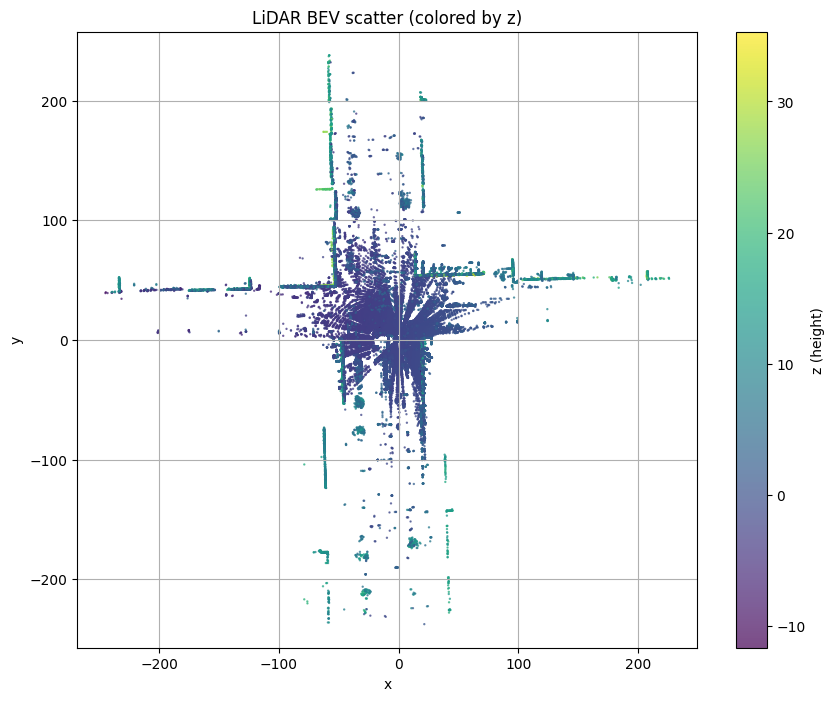

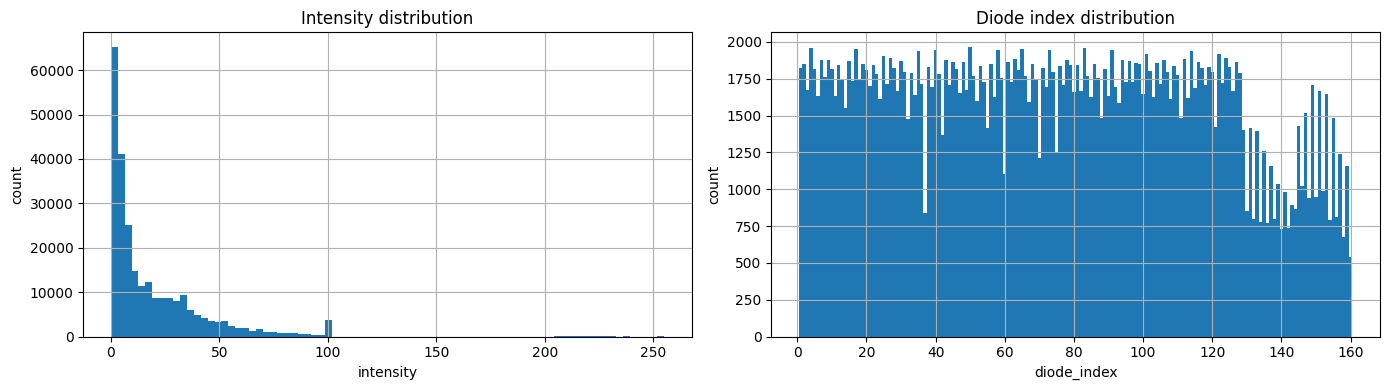

In [34]:
# Visualize the point cloud in BEV (x-y) with color by z.
# Subsample points to keep plotting responsive in notebook.
rng = np.random.default_rng(42)
idx = rng.choice(len(x), size=min(120_000, len(x)), replace=False)

plt.figure(figsize=(10, 8))
plt.scatter(x[idx], y[idx], c=z[idx], s=0.5, alpha=0.7)
plt.colorbar(label="z (height)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("LiDAR BEV scatter (colored by z)")
plt.axis("equal")
plt.show()

# Distribution checks: intensity and diode usage (laser rings).
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(intensity, bins=80)
axes[0].set_title("Intensity distribution")
axes[0].set_xlabel("intensity")
axes[0].set_ylabel("count")

axes[1].hist(diode, bins=np.arange(diode.min(), diode.max() + 2) - 0.5)
axes[1].set_title("Diode index distribution")
axes[1].set_xlabel("diode_index")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

## 4) Pedestrian annotation structure (what matters for detection)

For each object in `annotations/object_detection.json`, common fields are:

- `properties.class` (e.g., `Pedestrian`)
- 2D image polygon-style footprint in `geometry.coordinates` (usually 4 points)
- quality flags like `unclear`, `occlusion_ratio`
- and sometimes 3D fields (location/size/orientation)

For pedestrian object detection, the practical pieces are:
- 2D geometry for image-space boxes
- class + unclear flag filtering
- optional 3D fields for deeper LiDAR/camera analysis

In [35]:
# Parse pedestrian annotations into a compact table.
ped_rows = []
for obj in od if isinstance(od, list) else []:
    props = obj.get("properties", {}) or {}
    if props.get("class") != "Pedestrian":
        continue

    coords = obj.get("geometry", {}).get("coordinates", [])
    arr = np.array(coords, dtype=float) if len(coords) else np.empty((0, 2))
    if arr.ndim == 2 and arr.shape[0] > 0 and arr.shape[1] >= 2:
        x_min, y_min = arr[:, 0].min(), arr[:, 1].min()
        x_max, y_max = arr[:, 0].max(), arr[:, 1].max()
    else:
        x_min = y_min = x_max = y_max = np.nan

    loc3d = props.get("location_3d", {}).get("coordinates", [None, None, None])

    ped_rows.append(
        {
            "annotation_uuid": props.get("annotation_uuid"),
            "unclear": props.get("unclear"),
            "occlusion_ratio": props.get("occlusion_ratio"),
            "bbox_xmin": x_min,
            "bbox_ymin": y_min,
            "bbox_xmax": x_max,
            "bbox_ymax": y_max,
            "loc3d_x": loc3d[0] if len(loc3d) > 0 else None,
            "loc3d_y": loc3d[1] if len(loc3d) > 1 else None,
            "loc3d_z": loc3d[2] if len(loc3d) > 2 else None,
            "size_3d_length": props.get("size_3d_length"),
            "size_3d_width": props.get("size_3d_width"),
            "size_3d_height": props.get("size_3d_height"),
        }
    )

ped_df = pd.DataFrame(ped_rows)
print(f"Pedestrian annotations found: {len(ped_df)}")
ped_df

Pedestrian annotations found: 57


,annotation_uuid,unclear,occlusion_ratio,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,loc3d_x,loc3d_y,loc3d_z,size_3d_length,size_3d_width,size_3d_height
0,04568424-8984-43df-8a2c-c6a9b11e71b6,False,VeryHeavy,1604.43,1102.42,1615.43,1132.92,-20.129077,99.194070,-2.009195,0.591543,0.723360,1.617166
1,056a0832-38be-4e2e-b2f9-2e9819aa9c34,False,Light,1009.43,1129.87,1022.64,1177.26,-34.510599,61.086533,-2.753642,0.579971,0.611364,1.732940
2,05ad26cd-31f0-417d-8d3f-fe8363ace714,False,Heavy,3369.10,1009.90,3398.32,1095.08,29.340589,31.906082,-0.187351,0.453005,0.603137,1.632441
3,0de2f384-41cb-4541-8f24-fb3f5dad72d4,False,Heavy,3039.13,1035.39,3055.86,1084.00,31.017481,49.135967,-0.195394,0.557473,0.683638,1.425419
4,0f075a78-e99b-477f-8bce-b316881c4ace,False,Medium,2192.31,1083.38,2209.53,1122.38,8.691926,75.655962,-1.445265,0.491516,0.770717,1.548592
5,10ac5d3a-edc2-4224-9663-5a6dc191eecd,False,Light,2695.71,1055.95,2725.98,1116.70,19.978265,49.755794,-0.770041,0.792137,0.493179,1.485036
6,1605a90d-8f3b-4919-9409-18b50237ef9d,False,Light,2151.56,1085.67,2167.85,1126.39,6.683734,72.630596,-1.496104,0.620809,0.666385,1.564000
7,17a7b46e-0b5d-462e-a1e3-ec8377066873,True,None,990.61,1133.00,999.72,1158.15,NaN,NaN,NaN,NaN,NaN,NaN
8,189b1166-2244-44a2-9420-d26fc6436892,False,None,3661.95,976.85,3716.59,1174.38,14.927204,12.079682,-0.585283,0.814734,0.667659,1.669926
9,1cbf35d8-7a20-4b51-9ac6-9776d9f80e3b,False,None,1497.04,1107.22,1507.90,1144.01,-20.307627,77.952412,-2.079156,0.439967,0.469577,1.393000


camera_img_path: /home/edgelab/zod_dino_data/train2017/000000/camera_front_dnat/000000_india_2021-04-19T10:23:10.444124Z.jpg


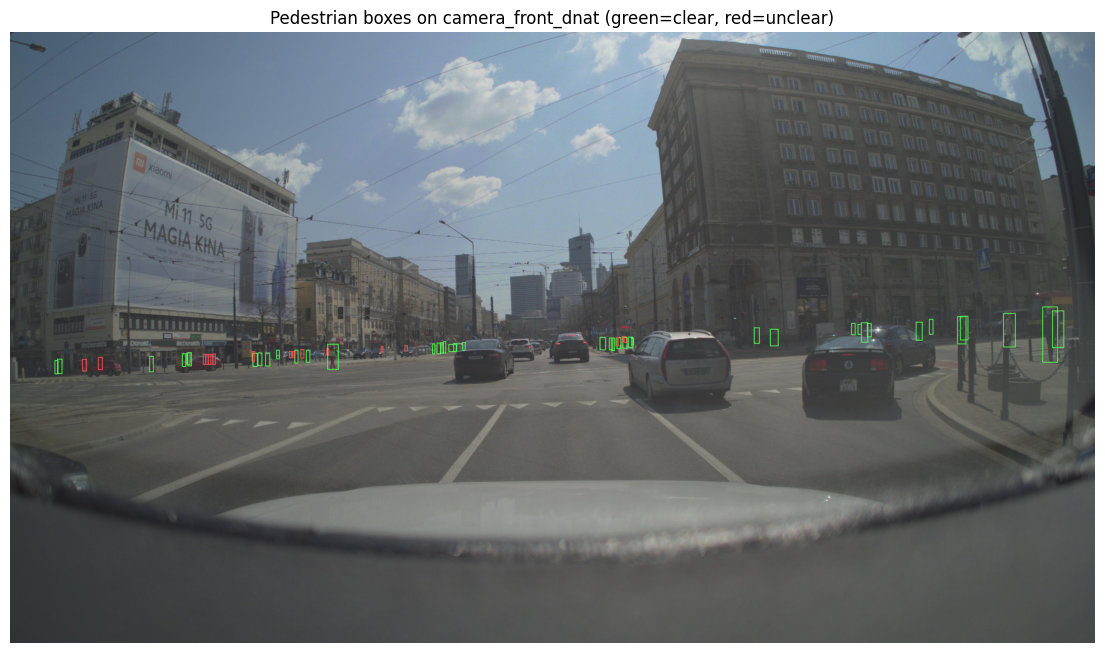

In [36]:
# Draw pedestrian boxes on camera image (if present locally).
def _resolve_front_dnat_image(frame_dir: Path, info_dict: dict) -> Path | None:
    # Preferred: local frame folder camera file.
    local_candidates = sorted((frame_dir / "camera_front_dnat").glob("*.jpg"))
    if local_candidates:
        return local_candidates[0]

    # Fallback: path listed in info.json (usually relative to a different root).
    try:
        rel = info_dict["camera_frames"]["front_dnat"][0]["filepath"]
        rel_path = Path(rel)
        # Try under current train root first.
        maybe = ORIGINAL_ZOD_ROOT / rel_path.name
        if maybe.exists():
            return maybe
    except Exception:
        pass

    return None


camera_img_path = _resolve_front_dnat_image(FRAME_DIR, info)
print("camera_img_path:", camera_img_path)

if camera_img_path is None or not camera_img_path.exists():
    print("Camera image not found locally in this subset. Skipping image overlay.")
else:
    img = Image.open(camera_img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for _, r in ped_df.iterrows():
        if np.isnan(r["bbox_xmin"]):
            continue
        # Unclear annotations use a different color for fast sanity checks.
        color = (255, 80, 80) if bool(r["unclear"]) else (80, 255, 80)
        draw.rectangle(
            [float(r["bbox_xmin"]), float(r["bbox_ymin"]), float(r["bbox_xmax"]), float(r["bbox_ymax"])],
            outline=color,
            width=3,
        )

    plt.figure(figsize=(14, 8))
    plt.imshow(np.array(img))
    plt.title("Pedestrian boxes on camera_front_dnat (green=clear, red=unclear)")
    plt.axis("off")
    plt.show()

## 6) Temporal context: one keyframe, many sweeps

I also want to see the sweep timeline explicitly. This confirms whether I have:
- a full local set of sweeps
- a partial set
- and where the camera keyframe sits in that window.

This is exactly why the LiDAR folder can look “too crowded” compared to camera frames.

,time,dt_from_keyframe_s,is_present_local,is_compensated,filepath
0,2021-04-19T10:23:09.306996Z,-1.137128,False,False,single_frames/000000/lidar_velodyne/000000_ind...
1,2021-04-19T10:23:09.417964Z,-1.026160,False,False,single_frames/000000/lidar_velodyne/000000_ind...
2,2021-04-19T10:23:09.528932Z,-0.915192,True,False,single_frames/000000/lidar_velodyne/000000_ind...
3,2021-04-19T10:23:09.639900Z,-0.804224,True,False,single_frames/000000/lidar_velodyne/000000_ind...
4,2021-04-19T10:23:09.750868Z,-0.693256,True,False,single_frames/000000/lidar_velodyne/000000_ind...
5,2021-04-19T10:23:09.861836Z,-0.582288,True,False,single_frames/000000/lidar_velodyne/000000_ind...
6,2021-04-19T10:23:09.972804Z,-0.471320,False,False,single_frames/000000/lidar_velodyne/000000_ind...
7,2021-04-19T10:23:10.083772Z,-0.360352,False,False,single_frames/000000/lidar_velodyne/000000_ind...
8,2021-04-19T10:23:10.194740Z,-0.249384,False,False,single_frames/000000/lidar_velodyne/000000_ind...
9,2021-04-19T10:23:10.305708Z,-0.138416,True,False,single_frames/000000/lidar_velodyne/000000_ind...


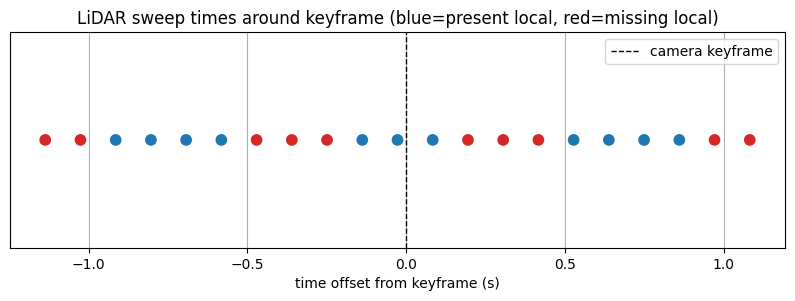

In [37]:
manifest_df = pd.DataFrame(lidar_manifest)
if not manifest_df.empty:
    manifest_df["time_dt"] = manifest_df["time"].apply(_iso_to_dt)
    manifest_df["is_present_local"] = manifest_df["filepath"].apply(lambda s: (LIDAR_DIR / Path(s).name).exists())
    manifest_df = manifest_df.sort_values("time_dt").reset_index(drop=True)

    manifest_df["dt_from_keyframe_s"] = manifest_df["time_dt"].apply(
        lambda t: (t - keyframe_time).total_seconds()
    )

    display_cols = ["time", "dt_from_keyframe_s", "is_present_local", "is_compensated", "filepath"]
    display(manifest_df[display_cols])

    plt.figure(figsize=(10, 2.8))
    colors = manifest_df["is_present_local"].map({True: "tab:blue", False: "tab:red"})
    plt.scatter(manifest_df["dt_from_keyframe_s"], np.zeros(len(manifest_df)), c=colors, s=55)
    plt.axvline(0.0, color="black", linestyle="--", linewidth=1, label="camera keyframe")
    plt.yticks([])
    plt.xlabel("time offset from keyframe (s)")
    plt.title("LiDAR sweep times around keyframe (blue=present local, red=missing local)")
    plt.legend(loc="upper right")
    plt.show()
else:
    print("No lidar manifest found in info.json")

In [38]:
# Quick class-level summary from object_detection annotations.
# This helps me see the full labeling context around pedestrians.
class_rows = []
for obj in od if isinstance(od, list) else []:
    props = obj.get("properties", {}) or {}
    cls = props.get("class", "<missing>")
    has_3d = (
        props.get("location_3d") is not None
        and props.get("size_3d_length") is not None
        and props.get("size_3d_width") is not None
        and props.get("size_3d_height") is not None
    )
    class_rows.append(
        {
            "class": cls,
            "unclear": bool(props.get("unclear", False)),
            "has_full_3d_fields": bool(has_3d),
        }
    )

class_df = pd.DataFrame(class_rows)
if class_df.empty:
    print("No object annotations loaded.")
else:
    summary = (
        class_df.groupby("class")
        .agg(
            n=("class", "size"),
            n_unclear=("unclear", "sum"),
            n_with_full_3d=("has_full_3d_fields", "sum"),
        )
        .sort_values("n", ascending=False)
    )
    display(summary)

    if "Pedestrian" in summary.index:
        ped_summary = summary.loc[["Pedestrian"]]
        print("\nPedestrian-specific summary:")
        display(ped_summary)

,n,n_unclear,n_with_full_3d
class,,,
Pedestrian,57,17,42
TrafficGuide,52,5,6
PoleObject,49,2,36
Vehicle,46,8,36
TrafficSignal,37,3,27
TrafficSign,35,5,30
VulnerableVehicle,5,0,5



Pedestrian-specific summary:


,n,n_unclear,n_with_full_3d
class,,,
Pedestrian,57,17,42


## Takeaways

- **Why many `.npy` files?**
  - One keyframe folder contains a *time window* of LiDAR sweeps, not a single sweep.
  - The camera keyframe is one timestamp inside that interval.

- **What does one `.npy` represent?**
  - A structured point cloud for one LiDAR sweep (`x,y,z,intensity,diode_index,timestamp`).

- **How do annotations relate?**
  - Object annotations live in camera image geometry plus object properties.
  - For pedestrians, I can derive 2D boxes from multipoints and use optional 3D fields when present.

- **Camera-LiDAR relationship in this dataset:**
  - Calibration provides intrinsics/extrinsics for cross-modal mapping.
  - Quick pinhole projection is enough for sanity checks, but precise work should handle camera distortion explicitly.

- **Practical note for experiments:**
  - If local LiDAR sweeps are missing vs `info.json`, that means my local copy is partial; I should account for this in any temporal fusion experiment.

## 8) BEVFusion-style camera-to-BEV lifting (not camera-to-point fusion)

BEVFusion-style fusion maps camera image features directly into BEV space through a lift-and-splat pipeline.

This section follows that idea using a practical proxy:

1. Build a sparse camera-depth support from projected LiDAR points.
2. Back-project valid image pixels with depth into 3D.
3. Transform those 3D points into LiDAR/ego frame.
4. Splat image features into a BEV grid.

This is still an exploration notebook, so the depth component is intentionally simplified (sparse support instead of a learned depth head).

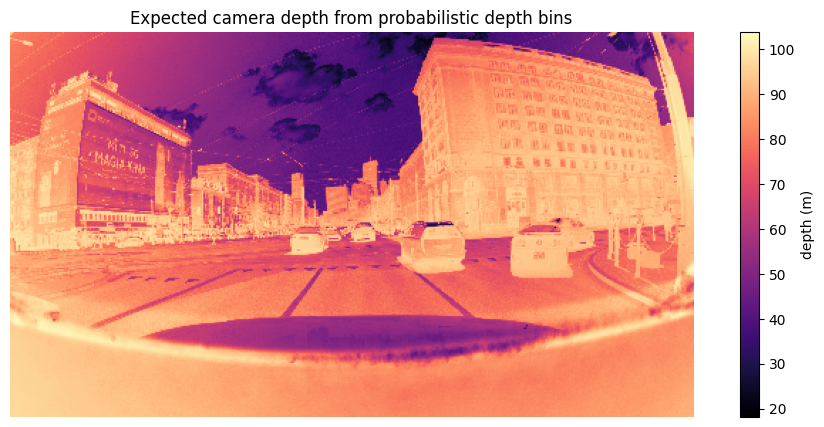

Full image shape: (2168, 3848, 3)
Lift image shape: (271, 481, 3)
Camera feature map shape: (271, 481, 4)
Depth probability shape: (271, 481, 24)
Depth bins: 24 [2.0, 120.0] m


In [39]:
# Helper utilities for BEVFusion-style camera lifting.
def _camera_feature_map(img: np.ndarray):
    """Create a lightweight feature map from RGB and edge magnitude."""
    gray = img.mean(axis=2)

    gx = np.zeros_like(gray)
    gy = np.zeros_like(gray)
    gx[:, 1:-1] = gray[:, 2:] - gray[:, :-2]
    gy[1:-1, :] = gray[2:, :] - gray[:-2, :]
    edge = np.sqrt(gx * gx + gy * gy)

    feat = np.stack([img[..., 0], img[..., 1], img[..., 2], edge], axis=-1).astype(np.float32)
    return feat


def _depth_bin_centers(d_min: float, d_max: float, n_bins: int) -> np.ndarray:
    """Uniform depth-bin centers used for camera frustum lifting."""
    return np.linspace(d_min, d_max, n_bins, dtype=np.float32)


def _depth_logits_from_image(gray: np.ndarray, bin_centers: np.ndarray) -> np.ndarray:
    """Heuristic per-pixel depth logits over bins.

    Brighter regions are weakly biased toward nearer bins to create a usable
    exploratory signal without LiDAR-projected depth.
    """
    n_bins = len(bin_centers)

    gray_n = (gray - gray.min()) / (gray.max() - gray.min() + 1e-6)
    near_bias = (1.0 - gray_n)[..., None]

    z = np.arange(n_bins, dtype=np.float32)[None, None, :]
    center_idx = (n_bins - 1) * near_bias
    logits = -((z - center_idx) ** 2) / (2.0 * (0.18 * n_bins) ** 2)

    return logits.astype(np.float32)


def _softmax_last(x: np.ndarray) -> np.ndarray:
    # Memory-stable softmax on last axis.
    x = x - x.max(axis=-1, keepdims=True)
    np.exp(x, out=x)
    x /= (x.sum(axis=-1, keepdims=True) + 1e-9)
    return x


def _robust_norm(a: np.ndarray, q_low: float = 1.0, q_high: float = 99.0) -> np.ndarray:
    """Robust normalization for stable visualizations."""
    lo = np.percentile(a, q_low)
    hi = np.percentile(a, q_high)
    if hi <= lo:
        return np.zeros_like(a)
    out = (a - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0)


K_3x4 = np.array(calib["FC"]["intrinsics"], dtype=np.float64)
K = K_3x4[:, :3]
fx_full, fy_full = K[0, 0], K[1, 1]
cx_full, cy_full = K[0, 2], K[1, 2]

if camera_img_path is None or not camera_img_path.exists():
    print("Camera image not available locally. Camera-to-BEV lifting cells will skip execution.")
else:
    img_full = np.array(Image.open(camera_img_path).convert("RGB"), dtype=np.float32) / 255.0
    full_h, full_w = img_full.shape[:2]

    # Controlled lift resolution to avoid kernel OOM.
    LIFT_DOWNSAMPLE = 8
    img = img_full[::LIFT_DOWNSAMPLE, ::LIFT_DOWNSAMPLE, :]
    img_h, img_w = img.shape[:2]

    # Intrinsics are rescaled to match the downsampled image grid.
    sx = img_w / full_w
    sy = img_h / full_h
    fx, fy = fx_full * sx, fy_full * sy
    cx, cy = cx_full * sx, cy_full * sy

    feat_map = _camera_feature_map(img)
    gray = img.mean(axis=2)

    # Reduced bins for exploratory runtime/memory.
    bin_centers = _depth_bin_centers(d_min=2.0, d_max=120.0, n_bins=24)
    depth_logits = _depth_logits_from_image(gray, bin_centers)
    depth_prob = _softmax_last(depth_logits)

    exp_depth = (depth_prob * bin_centers[None, None, :]).sum(axis=-1)

    plt.figure(figsize=(12, 5))
    plt.imshow(exp_depth, cmap="magma")
    plt.title("Expected camera depth from probabilistic depth bins")
    plt.colorbar(label="depth (m)")
    plt.axis("off")
    plt.show()

    print("Full image shape:", img_full.shape)
    print("Lift image shape:", img.shape)
    print("Camera feature map shape:", feat_map.shape)
    print("Depth probability shape:", depth_prob.shape)
    print("Depth bins:", len(bin_centers), f"[{bin_centers.min():.1f}, {bin_centers.max():.1f}] m")

In [40]:
# Lift camera features into BEV using probabilistic depth bins.
if camera_img_path is None or not camera_img_path.exists():
    print("Camera image not available locally. BEV lifting cell skipped.")
else:
    # Downsample for tractable lifting in notebook runtime.
    step = 12
    ys = np.arange(0, img_h, step)
    xs = np.arange(0, img_w, step)
    xx, yy = np.meshgrid(xs, ys)

    # Gather per-pixel features and depth probabilities.
    feat_ds = feat_map[yy, xx, :]                     # [Hds, Wds, C]
    prob_ds = depth_prob[yy, xx, :]                   # [Hds, Wds, D]

    u = xx[..., None].astype(np.float64)              # [Hds, Wds, 1]
    v = yy[..., None].astype(np.float64)              # [Hds, Wds, 1]
    z = bin_centers[None, None, :].astype(np.float64) # [1, 1, D]

    # Camera frustum points per depth bin.
    x_cam = (u - cx) * z / fx
    y_cam = (v - cy) * z / fy
    z_cam = np.broadcast_to(z, x_cam.shape)

    # Flatten frustum grid.
    xyz_cam = np.stack([x_cam, y_cam, z_cam], axis=-1).reshape(-1, 3)
    w_depth = prob_ds.reshape(-1)  # per (pixel, depth-bin) weight

    # Expand image feature vectors across depth bins.
    C = feat_ds.shape[-1]
    feat_flat = np.repeat(feat_ds.reshape(-1, C), repeats=len(bin_centers), axis=0)

    # Camera -> LiDAR frame.
    # This cell is made self-contained so it can run without relying on earlier cells.
    if "T_lidar_to_cam" not in globals():
        T_candidate = np.array(calib["FC"]["lidar_extrinsics"], dtype=np.float64)

        # Try both conventions and choose the one that projects more LiDAR points into the image.
        # Build LiDAR XYZ directly from the structured point cloud to avoid name-collision issues
        # with notebook variables like x/y/z used in plotting cells.
        if "pts" in globals() and isinstance(pts, np.ndarray) and pts.dtype.names is not None:
            xyz_lidar_ref = np.stack(
                [pts["x"].astype(np.float64), pts["y"].astype(np.float64), pts["z"].astype(np.float64)],
                axis=1,
            )
        else:
            # Fallback: load from current sweep path if pts is not available.
            pts_local = np.load(closest_lidar_path)
            xyz_lidar_ref = np.stack(
                [pts_local["x"].astype(np.float64), pts_local["y"].astype(np.float64), pts_local["z"].astype(np.float64)],
                axis=1,
            )

        xyz1_all = np.concatenate([xyz_lidar_ref, np.ones((xyz_lidar_ref.shape[0], 1), dtype=np.float64)], axis=1)

        def _in_image_count(T_test: np.ndarray) -> int:
            xyz_cam_h = (T_test @ xyz1_all.T).T
            xyz_cam = xyz_cam_h[:, :3]
            zc = xyz_cam[:, 2]
            m = zc > 0.1
            if not np.any(m):
                return 0
            uvw = (K @ xyz_cam[m].T).T
            u = uvw[:, 0] / uvw[:, 2]
            v = uvw[:, 1] / uvw[:, 2]
            in_img = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
            return int(in_img.sum())

        c_a = _in_image_count(T_candidate)
        c_b = _in_image_count(np.linalg.inv(T_candidate))
        T_lidar_to_cam = np.linalg.inv(T_candidate) if c_b > c_a else T_candidate

    T_cam_to_lidar = np.linalg.inv(T_lidar_to_cam)
    xyz_cam1 = np.concatenate([xyz_cam, np.ones((xyz_cam.shape[0], 1), dtype=np.float64)], axis=1)
    xyz_l = (T_cam_to_lidar @ xyz_cam1.T).T[:, :3]

    # BEV bounds and resolution.
    x_min, x_max = -40.0, 40.0
    y_min, y_max = 0.0, 120.0
    res = 0.5

    bev_w = int(np.ceil((x_max - x_min) / res))
    bev_h = int(np.ceil((y_max - y_min) / res))

    bx = ((xyz_l[:, 0] - x_min) / res).astype(np.int32)
    by = ((xyz_l[:, 1] - y_min) / res).astype(np.int32)
    in_bev = (bx >= 0) & (bx < bev_w) & (by >= 0) & (by < bev_h) & (w_depth > 1e-4)

    bx = bx[in_bev]
    by = by[in_bev]
    ww = w_depth[in_bev].astype(np.float32)
    ff = feat_flat[in_bev].astype(np.float32)

    # Weighted splat into BEV.
    bev_sum = np.zeros((bev_h, bev_w, C), dtype=np.float32)
    bev_wsum = np.zeros((bev_h, bev_w), dtype=np.float32)

    for i in range(len(bx)):
        bev_sum[by[i], bx[i]] += ww[i] * ff[i]
        bev_wsum[by[i], bx[i]] += ww[i]

    bev_cam = np.zeros_like(bev_sum)
    nz = bev_wsum > 1e-8
    bev_cam[nz] = bev_sum[nz] / bev_wsum[nz, None]

    # LiDAR occupancy for geometric reference.
    if "pts" in globals() and isinstance(pts, np.ndarray) and pts.dtype.names is not None:
        xyz_lidar_occ = np.stack(
            [pts["x"].astype(np.float64), pts["y"].astype(np.float64), pts["z"].astype(np.float64)],
            axis=1,
        )
    else:
        pts_local = np.load(closest_lidar_path)
        xyz_lidar_occ = np.stack(
            [pts_local["x"].astype(np.float64), pts_local["y"].astype(np.float64), pts_local["z"].astype(np.float64)],
            axis=1,
        )

    occ = np.zeros((bev_h, bev_w), dtype=np.float32)
    bx_l = ((xyz_lidar_occ[:, 0] - x_min) / res).astype(np.int32)
    by_l = ((xyz_lidar_occ[:, 1] - y_min) / res).astype(np.int32)
    m_l = (bx_l >= 0) & (bx_l < bev_w) & (by_l >= 0) & (by_l < bev_h)
    occ[by_l[m_l], bx_l[m_l]] += 1.0
    occ = np.log1p(occ)

    # Robust normalization prevents all-white/all-black plots.
    r_vis = _robust_norm(bev_cam[..., 0])
    rgb_vis = np.stack([
        _robust_norm(bev_cam[..., 0]),
        _robust_norm(bev_cam[..., 1]),
        _robust_norm(bev_cam[..., 2]),
    ], axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(np.flipud(occ), cmap="gray")
    axes[0].set_title("LiDAR BEV occupancy (log count)")
    axes[0].axis("off")

    axes[1].imshow(np.flipud(r_vis), cmap="magma")
    axes[1].set_title("Camera->BEV lifted feature (R channel, normalized)")
    axes[1].axis("off")

    axes[2].imshow(np.flipud(rgb_vis))
    axes[2].set_title("Camera->BEV lifted feature (RGB, normalized)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Frustum samples rasterized into BEV: {len(bx):,}")
    print(f"Non-empty BEV cells (camera features): {int((bev_wsum > 0).sum()):,}")

ValueError: all input arrays must have the same shape